In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
## noul modul importat
import matplotlib.animation as animation
from IPython.display import HTML

In [16]:
df = pd.read_csv("world_cup.csv")
df = df[["Year", "Winner"]]
df

,Year,Winner
0,1930,Uruguay
1,1934,Italy
2,1938,Italy
3,1950,Uruguay
4,1954,Germany FR
5,1958,Brazil
6,1962,Brazil
7,1966,England
8,1970,Brazil
9,1974,Germany FR


In [10]:
serie_winners = df.Winner.value_counts()
serie_winners

Winner
Brazil        5
Italy         4
Germany FR    3
Argentina     3
Uruguay       2
France        2
England       1
Spain         1
Germany       1
Name: count, dtype: int64

Text(0.5, 0, 'Number of wins')

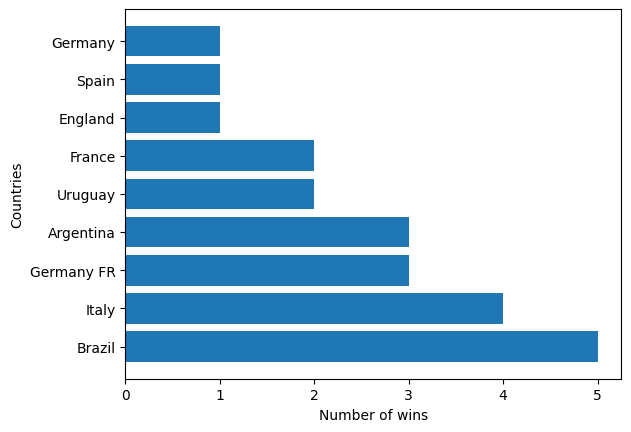

In [12]:
figure, axis = plt.subplots()

axis.barh(serie_winners.index, serie_winners.values)
axis.set_ylabel("Countries")
axis.set_xlabel("Number of wins")

In [14]:
before_70_df = df[["Year", "Winner"]] [df["Year"] < 1970]
before_70_df

,Year,Winner
0,1930,Uruguay
1,1934,Italy
2,1938,Italy
3,1950,Uruguay
4,1954,Germany FR
5,1958,Brazil
6,1962,Brazil
7,1966,England


Text(0.5, 0, 'Number of wins')

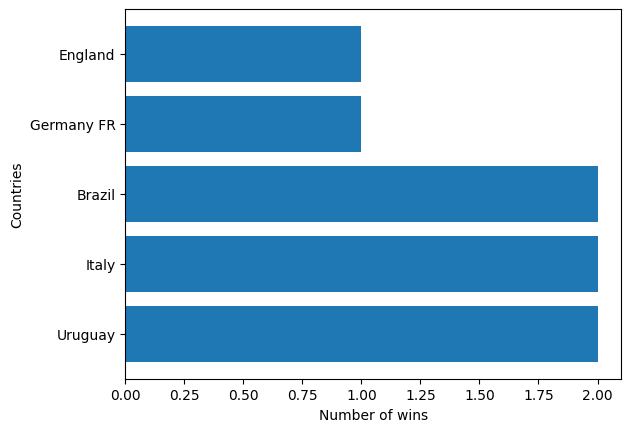

In [15]:
figure, axis = plt.subplots()

before_70_serie_winners = before_70_df.Winner.value_counts()

axis.barh(before_70_serie_winners.index, before_70_serie_winners.values)
axis.set_ylabel("Countries")
axis.set_xlabel("Number of wins")

In [19]:
print(list(df.Year))

[1930, 1934, 1938, 1950, 1954, 1958, 1962, 1966, 1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]


In [28]:
figure, axis = plt.subplots()

def update_function(year):
    axis.clear()
    current_df:pd.DataFrame = df[df["Year"] <= year]
    current_winners = current_df.Winner.value_counts()
    
    bars = axis.barh(current_winners.index, current_winners.values, color="skyblue")
    axis.set_ylabel("Countries")
    axis.set_xlabel("Number of wins")
    return bars

ani = animation.FuncAnimation(fig=figure, func=update_function, frames=list(df.Year), repeat=True, interval=1000)
ani.save("winners.gif", writer="ffmpeg")



plt.close();
HTML(ani.to_jshtml())